# Datascience Gruppenarbeit

Wir schauen uns für unsere Gruppenarbeit das TMDB Movie Dataset an. Es enthält Informationen zu Filmen, die auf der Plattform TMDB (The Movie Database) verfügbar sind. Das Dataset enthält eine Vielzahl von Attributen, darunter Titel, Genre, Veröffentlichungsdatum, Budget, Einnahmen und viele andere.

> Da der Datensatz täglich aktualisiert wird, haben wir uns dazu entschieden mit dem Datensatz von einem bestimmten Tag zu arbeiten, damit wir sicher stellen können, dass wir beim Ausführen des gleichen Code an unterschiedlichen Tagen, trotzdem immer das gleiche Ergebnis bekommen.
> Wir haben uns für die Version `518` des Datensatzes entschieden, welche am **22. März 2025** veröffentlicht worden ist.

## Gruppenmitglieder
- Victoria Bischof
- Laurenz Mages
- Philipp Gremeyer
- Patrick Pfurtscheller

In [1]:
# setup caching via csv files
import os
import pandas as pd

CACHE_DIR = './cache/10_chapter_one'

# Ensure the cache directory exists
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)

def write_df_to_csv(df, filename):
    """
    Write a DataFrame to a CSV file in the cache directory.
    """
    filepath = os.path.join(CACHE_DIR, filename)
    df.to_csv(filepath, index=False)

def read_df_from_csv(filename):
    """
    Read a DataFrame from a CSV file in the cache directory.
    """
    filepath = os.path.join(CACHE_DIR, filename)
    if os.path.exists(filepath):
        return pd.read_csv(filepath)
    else:
        raise FileNotFoundError(f"Cache file {filename} not found in {CACHE_DIR}.")

## Datenbeschreibung

Zu Beginn möchten wir uns anschauen, was der Datensatz denn für Daten enthält.
Daher haben wir ihn geladen und uns die Anzahl an Einträgen und die einzelnen Features angeschaut.

In [2]:
# Import necessary libraries
import pandas as pd
import kagglehub
import numpy as np
from kagglehub import KaggleDatasetAdapter

# Load the dataset using KaggleHub
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/518",
    "TMDB_movie_dataset_v11.csv",)

# Inspect the features and row count
print(f'Number of rows: { df.shape[0] }')
print(f'Number of features: { df.shape[1] }')
print('\nFeatures:')
for feature in df.columns:
  print(f'-> { feature }')

Number of rows: 1195824
Number of features: 24

Features:
-> id
-> title
-> vote_average
-> vote_count
-> status
-> release_date
-> revenue
-> runtime
-> adult
-> backdrop_path
-> budget
-> homepage
-> imdb_id
-> original_language
-> original_title
-> overview
-> popularity
-> poster_path
-> tagline
-> genres
-> production_companies
-> production_countries
-> spoken_languages
-> keywords


## Datenaufbereitung

Bevor wir den Datensatz für die Auswertung verwenden, müssen wir ihn aufbereiten. Dies erfolgt in mehreren Schritten.

### Entfernen nicht benötigter Spalten

Wir haben uns entschieden, einige Spalten zu entfernen, die für unsere Analyse nicht relevant sind. Dazu gehören:

- `id`
- `status`
- `backgrop_path`
- `poster_path`
- `homepage`
- `imdb_id`

In [3]:
# Drop unnecessary columns
df_drop_colums = df.drop(columns=['id', 'status', 'backdrop_path', 'poster_path', 'homepage', 'imdb_id'])
df_drop_colums.columns

Index(['title', 'vote_average', 'vote_count', 'release_date', 'revenue',
       'runtime', 'adult', 'budget', 'original_language', 'original_title',
       'overview', 'popularity', 'tagline', 'genres', 'production_companies',
       'production_countries', 'spoken_languages', 'keywords'],
      dtype='object')

### Entfernen der ältesten Filme

Da wir uns für die Analyse auf neuere Filme konzentrieren möchten, haben wir uns entschieden, die ältesten Filme aus dem Datensatz zu entfernen. Wir haben uns dazu entschieden, **die ältesten 10%** der Filme zu entfernen. Dies bedeutet, dass wir Filme die vor 1967 veröffentlicht wurden nicht mehr in der Analyse berücksichtigen.

In [4]:
# Sort by date
df_remove_old_movies = df_drop_colums.sort_values(by='release_date', ascending=True)
# Calculate the index to drop the oldest 10% of movies
drop_threshold_index = int(df_remove_old_movies.shape[0]*0.1)
# Drop the oldest 10% of movies
df_remove_old_movies = df_remove_old_movies.iloc[drop_threshold_index:]
df_remove_old_movies.head()["release_date"]

del df_drop_colums

### Filmübersetzungen
Da der Datensatz sowohl die Originalproduktion eines Films, als auch die Übersetzung in jeder Sprache beinhaltet, haben wir uns dazu entschlossen alle Filme, bei denen der Originaltitel un der Titel nicht identisch sind, aus dem Dataframe zu entfernen.
Hier konnten wir nicht mit Sicherheit sagen, ob die Filme den Datensatz verzerren würden. 
Bei der Gelegenheit trennen wir uns auch gleich von der spalte `original_title`, da wir diese nicht mehr benötigen.

In [5]:
# Sort by original title
df_group_og_title = df_remove_old_movies.sort_values(by='original_title', ascending=True)

# Remove all movies that have a different title than the original title
index_names = df_group_og_title[df_group_og_title['original_title'] != df_group_og_title['title']].index
df_group_og_title.drop(index_names, inplace=True)
# drop the 'original_title' column
df_group_og_title.drop(columns=['original_title'], inplace=True)

print(f'Reduced dataset size from {df_remove_old_movies.shape[0]} to {df_group_og_title.shape[0]}')

Reduced dataset size from 1076242 to 872077


### <del>Null und NaN Werte in den Titeln</del>
<del>Wir entfernen alle Filme, deren Titel NaN oder Null Werte enthalten.</del>

In [ ]:
# Seems to do nothing, therefore commented out

# # df_group_og_title_no_na = df_group_og_title[(df_group_og_title['title'].notna()) & (df_group_og_title['title'] != 'NaN') & (df_group_og_title['title'] != '')]
# print(f'Reduced dataset size from {df_group_og_title.shape[0]} to {df_group_og_title_no_na.shape[0]}')

### Entfernen von Duplikaten
Entfernen jeglicher Duplikate von kompletten Spalten

In [6]:
# drop any duplicates left in the dataset
df_no_dublicates = df_group_og_title.drop_duplicates(keep='first')
print(f'Reduced dataset size from {df_group_og_title.shape[0]} to {df_no_dublicates.shape[0]}')

Reduced dataset size from 872077 to 870328


### Ideen für eine weitere Aufbereitung der Daten

- Zusammenfassen von mehrfach veröffentlichten Filmen in mehreren Ländern/Sprachen
  - Idee: Matchen der Filme anhand des original_title und dann neu Berechnung der Spalten "vote_average" und "vote_count" als weighted average über die Länder hinweg

## Ideen für die Verwendung der Feautures

- Popularity kann nicht genutzt werden, da sich der Wert aus verschiedenen Anzeichen für die Beliebtheit eines Filmes ergibt. Somit ist zu erwarten, dass ein direkter Zusammenhang mit dem Umsatz etc besteht
- Relevante Spalten für Vorhersagen: title, budget, original_language, overview, tagline, genres, production_companies, production_countries, spoken_languages, keywords

## RAM Cleanup

Da der Datensatz sehr groß ist, haben wir uns dazu entschieden, den RAM aufzuräumen, um die Performance zu verbessern. Dies erfolgt durch das Entfernen von nicht mehr benötigten Variablen und das Freigeben von Speicherplatz.

In [7]:
import gc

write_df_to_csv(df_no_dublicates, '10_data_cleanup.csv')

del df
del df_remove_old_movies
del df_group_og_title
del df_no_dublicates

gc.collect()

0

## Feature Engineering

### One Hot Encoding

Wir haben uns entschieden, die Spalten `genres` und `production_countries`mit One Hot Encoding zu kodieren. Dies ist notwendig, da diese Spalten einzelne Werte enthalten, die nicht direkt in ein numerisches Format umgewandelt werden können.

In [8]:
df_no_dublicates = read_df_from_csv('10_data_cleanup.csv')

# encode genres
encoded_genres = df_no_dublicates['genres'].str.replace(" ","").str.get_dummies(sep=',').add_prefix('genre_')
df_encoded = df_no_dublicates.drop('genres', axis=1).join(encoded_genres)

# encode production_countries
encoded_production_countries = df_encoded['production_countries'].str.replace(" ","").str.get_dummies(sep=',').add_prefix('country_')
df_encoded = df_encoded.drop('production_countries', axis=1).join(encoded_production_countries)

del encoded_genres
del encoded_production_countries

import gc
gc.collect()

52

### Profitabilität von Filmen

Wir haben uns entschieden, die Profitabilität von Filmen zu berechnen. Dies geschieht durch die Berechnung des Verhältnisses von Einnahmen zu Budget.
Außerdem haben wir uns entschieden, die Filme mit einem Budget von 0 zu entfernen, da diese unsere Berechnung verfälschen würden (Stichwort Division durch 0).
Des Weiteren haben wir uns entschlossen, Filme mit einem Revenue von 0 zu entfernen, da wir für diese Filme keine Aussage über die Profitabilität treffen können.
Außerdem haben wir uns entschlossen, Filme die eine Profitabilität über 5000% haben zu entfernen, da diese Filme nicht sehr repräsentativ sind und weitere Analysen erschweren.

In [9]:
# copy the dataframe
df_profitability = df_encoded.copy()

# convert the columns "vote_average", "budged" amd "revenue" to float
df_profitability['vote_average'] = df_profitability['vote_average'].astype(float)
df_profitability["budget"] = df_profitability["budget"].astype(float)
df_profitability["revenue"] = df_profitability["revenue"].astype(float)

# drop all columns with 0 budged or revenue

# Budget must not be 0 as it will result in a division by 0 and therefore inifinity
df_profitability = df_profitability[df_profitability['budget'] != 0]
# Revenue must not be 0 as it will result in a profitability of 0 and this will not be useful
# for the analyses as it will not be possible to determine if the movie was profitable or not
df_profitability = df_profitability[df_profitability['revenue'] != 0]

# calculate profitability
df_profitability['profitability'] = df_profitability['revenue'] / df_profitability['budget']
df_profitability['profitability'] = df_profitability['profitability'].astype(float)

df_profitability = df_profitability[df_profitability['profitability'] <= 50]

df_profitability.shape

(11515, 285)

## RAM Cleanup

In [10]:
import gc

write_df_to_csv(df_profitability, '20_feature_engineering.csv')

del df_encoded
del df_profitability
gc.collect()

0

## Clustering

### Erste Versuche

Zu Beginne haben wir begonnen die Filme in verschiedene Cluster zu unterteilen und dies mittels Variablen parametrisiert um schnell zu sehen, wie sich die Cluster verändern.

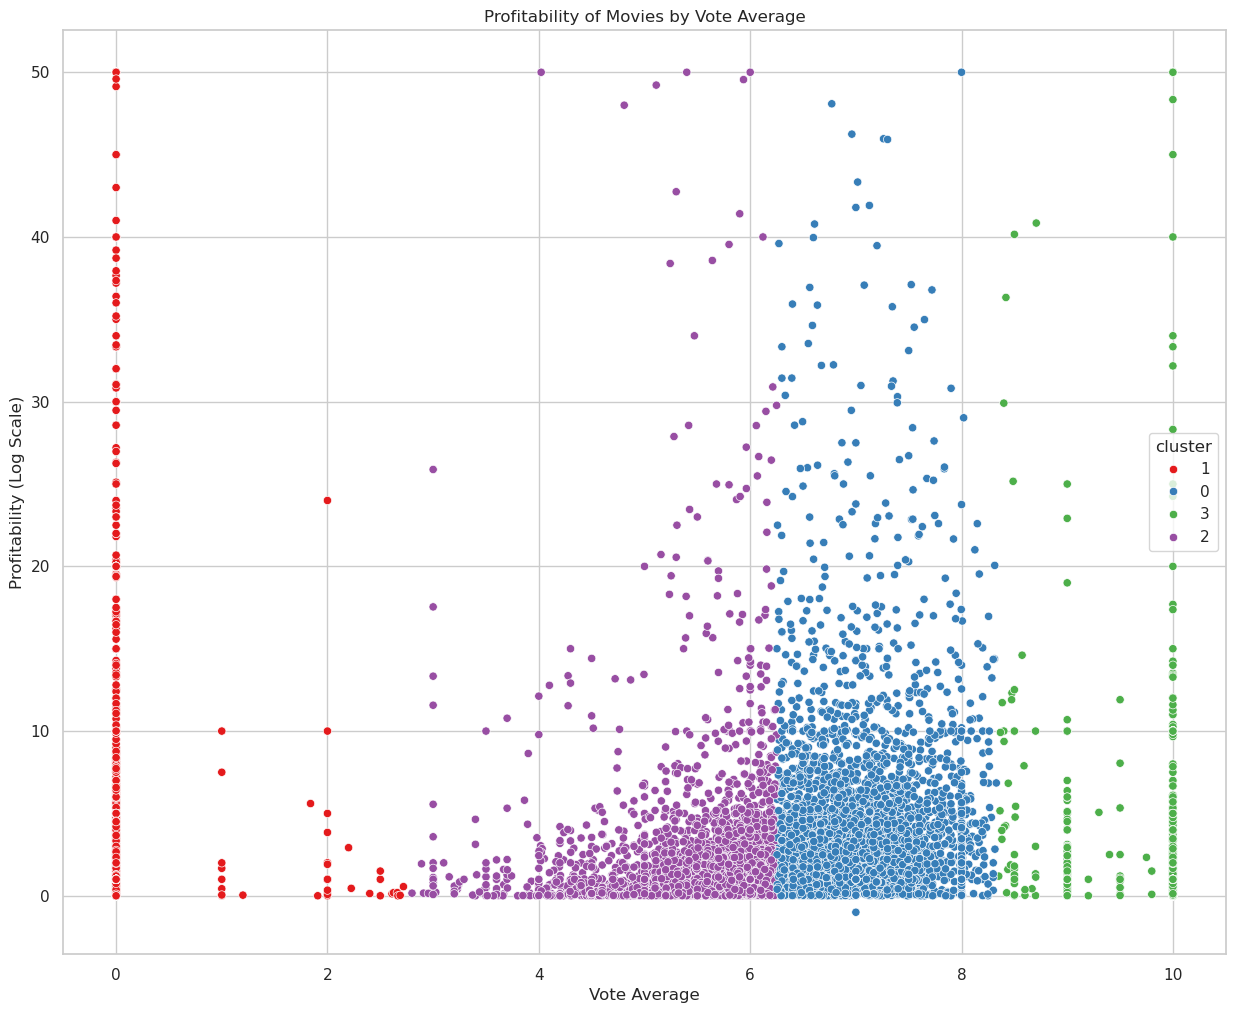

In [11]:
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

df_cluster_tries = read_df_from_csv('20_feature_engineering.csv')

# Global Settings
KMOIDS_OR_KMEANS = "kmeans"  # "kmeans" or "kmedoids"
CLUSTERS = 4  # number of clusters
CLUSTERING_DIMENSIONS = "vote_average_only" # "financial_only", "vote_average_and_financial" or "vote_average_only"

# create new kmeans or kmedoids object
if KMOIDS_OR_KMEANS == "kmeans":
    clustering = KMeans(n_clusters=CLUSTERS, random_state=0)
elif KMOIDS_OR_KMEANS == "kmedoids":
    clustering = KMedoids(n_clusters=CLUSTERS, random_state=0, metric="euclidean")
else:
    raise ValueError("KMOIDS_OR_KMEANS must be 'kmeans' or 'kmedoids'")

# df_profitability_vote_average.head()
if CLUSTERING_DIMENSIONS == "financial_only":
    clustering.fit(df_cluster_tries[['profitability']])
elif CLUSTERING_DIMENSIONS == "vote_average_and_financial":
    clustering.fit(df_cluster_tries[['vote_average','profitability']])
elif CLUSTERING_DIMENSIONS == "vote_average_only":
    clustering.fit(df_cluster_tries[['vote_average']])
else:
    raise ValueError("CLUSTERING_DIMENSIONS must be 'financial_only', 'vote_average_and_financial' or 'vote_average_only'")

# add the cluster labels to the dataframe and convert to string
df_cluster_tries['cluster'] = clustering.labels_
df_cluster_tries['cluster'] = df_cluster_tries['cluster'].astype(str)

# display clusters in a chart
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))
sns.scatterplot(x='vote_average', y='profitability', hue='cluster', data=df_cluster_tries, palette='Set1')
# plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Profitability of Movies by Vote Average')
plt.xlabel('Vote Average')
plt.ylabel('Profitability (Log Scale)')
plt.show()

del df_cluster_tries

### Finden der optimalen Clusteranzahl
Neben den manuellen ersten Versuchen, haben wir auch auch versucht etablierte Methoden zu verwenden, um die optimale Anzahl an Clustern zu finden. Dazu haben wir die Elbow-Method sowie die Silhouette-Analyse verwendet.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

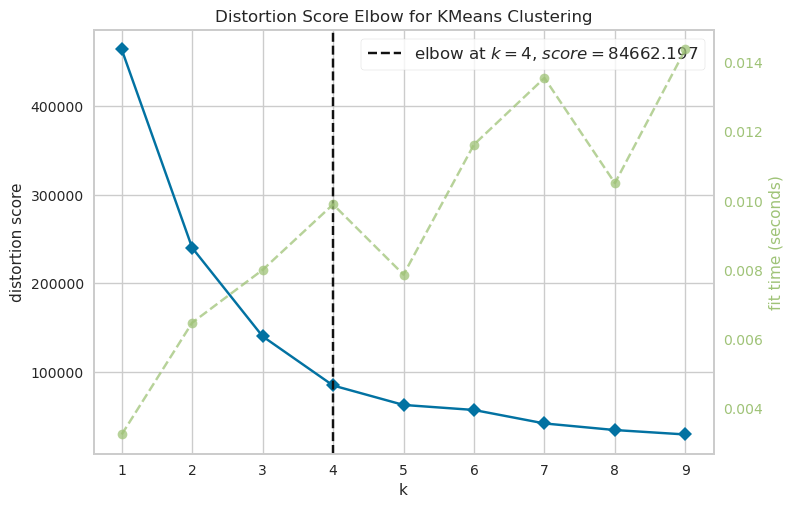

Anzahl Cluster: 2, Silhouette Score: 0.5270
Anzahl Cluster: 3, Silhouette Score: 0.5978
Anzahl Cluster: 4, Silhouette Score: 0.6351
Anzahl Cluster: 5, Silhouette Score: 0.5960
Anzahl Cluster: 6, Silhouette Score: 0.6111
Anzahl Cluster: 7, Silhouette Score: 0.5527
Anzahl Cluster: 8, Silhouette Score: 0.5545


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

Anzahl Cluster: 9, Silhouette Score: 0.5646

Optimale Anzahl an Clustern: 4


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


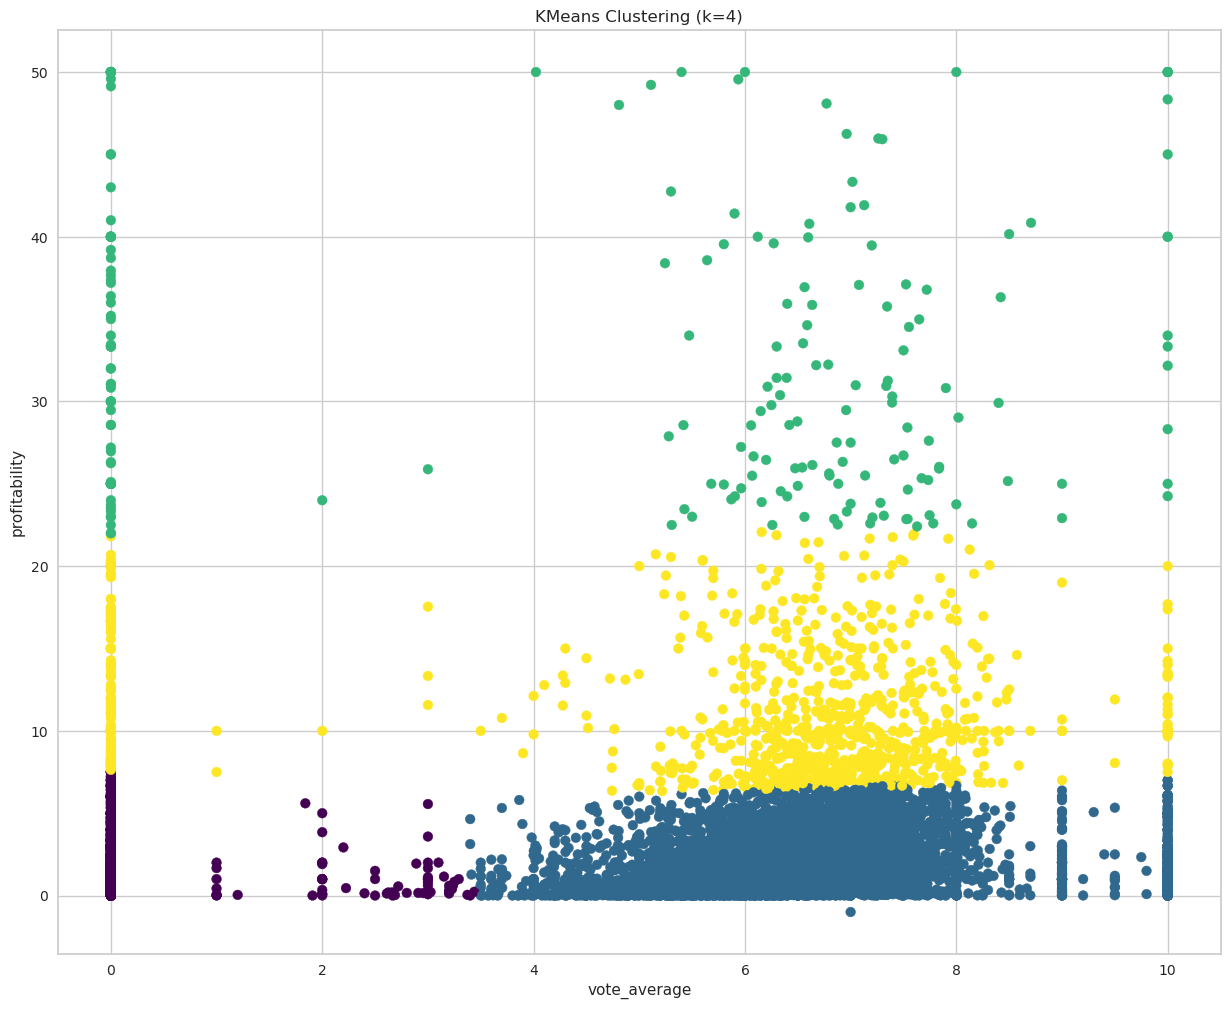

7130

In [12]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import gc

df_profitability = read_df_from_csv('20_feature_engineering.csv')
df_cluster_n = df_profitability.copy()

X = df_cluster_n[['vote_average', 'profitability']]

# Elbow Method
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1, 10))
visualizer.fit(X)
visualizer.show()

# Silhouette Score Method
silhouette_scores = []
range_n_clusters = range(2, 10)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"Anzahl Cluster: {n_clusters}, Silhouette Score: {score:.4f}")

optimal_n = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimale Anzahl an Clustern: {optimal_n}")


# Fit KMeans with the optimal number of clusters and plot the results
kmeans = KMeans(n_clusters=optimal_n, random_state=42)
df_cluster_n['cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(15, 12))
plt.scatter(df_cluster_n["vote_average"], df_cluster_n["profitability"], c=df_cluster_n["cluster"], cmap='viridis')
plt.xlabel("vote_average")
plt.ylabel("profitability")
plt.title(f"KMeans Clustering (k={optimal_n})")
plt.show()

# clean up ram
del df_profitability
del df_cluster_n
gc.collect()

### Ergebnisse der Clustering Versuche

Wir sehen, dass KMeans und KMedoids ähnliche Ergebnisse liefern.
Grundsätzlich haben wir bei beiden Probleme mit Outliers, die die Clusterbildung stören.
Deswegen mussten wir manuell sinnvolle Grenzen für die Profitabilität setzen.

Zusätzlich ist uns aufgefallen, dass die algorithmische Clusterbildung in unserem Business-Case nicht wirklich sinnvoll ist. Wir sehen zwar ein, dass eine Cluster Anzahl von 4 mathematisch logisch ist aber durch diese Begrenzung können wir keine "scharfen" Grenzen zwischen "profitablen" und "unprofitablen" Filmen ziehen.
Gleiches gilt für die Bewertung.

Deswegen sind wir zu dem Schluss gekommen, dass wir die Filme basierend auf den Clustering Ergebnissen manuell wie folgt einteilen werden.

Hierbei bauen wir uns drei Szenarien auf.

#### Szenario 1: Rein kapitalistische Sichtweise

##### Variablen für den Code Oben
```python
KMOIDS_OR_KMEANS = "kmoids"
CLUSTERS = 5
CLUSTERING_DIMENSIONS = "financial_only"
```

##### Cluster

|Bezeichnung                                        |Codierung | Bewertung    | Profitabilität|
|---------------------------------------------------|----------|-------------|---------------|
|Nicht profitabel                                  |         0|         egal |          <1 |
|Gerade noch profitabel                            |         1|         egal |         1 - 2 |
|Profitabel                                        |         2|         egal |         2 - 4 |
|Sehr profitabel                                   |         3|         egal |         4 - 8 |
|Blockbuster                                       |         4|         egal |         > 8 |

#### Szenario 2: Kapitalistische Sichtweise mit Berücksichtigung der Bewertung

##### Variablen für den Code Oben
```python
KMOIDS_OR_KMEANS = "kmoids"
CLUSTERS = 7
CLUSTERING_DIMENSIONS = "financial_and_rating"
```

#### Cluster

|Bezeichnung                                        |Codierung |Bewertung    | Profitabilität|
|---------------------------------------------------|----------|-------------|---------------|
|Müll Film                                          |         0|         < 4 |          egal |        
|Zu teuer (finanziell)                              |         1|         < 9 |           < 1 |     
|Fan Service (marketing)                            |         2|        >= 9 |           < 1 |
|Gerade noch profitabel aber nicht gut genug        |         3|         < 7 |         1 - 2 |
|Gerade noch profitabel                             |         4|        >= 7 |         1 - 2 |
|Profitabel                                         |         5|        >= 4 |         2 - 4 |
|Sehr profitabel                                    |         6|        >= 4 |         4 - 8 |
|Blockbuster                                        |         7|        >= 4 |         > 8   |

#### Szenario 3: Sichtweise rein auf Basis der Bewertung

##### Variablen für den Code Oben
```python
KMOIDS_OR_KMEANS = "kmeans"
CLUSTERS = 4
CLUSTERING_DIMENSIONS = "rating_only"
```
#### Cluster
|Bezeichnung                                        |Codierung |Bewertung    | Profitabilität|
|---------------------------------------------------|----------|-------------|---------------|
|Müll Film                                          |         0|         < 3 |          egal |
|Schlechter Film                                    |         1|         < 6 |          egal |
|Guter Film                                         |         2|         < 8 |          egal |
|Sehr guter Film                                    |         3|        >= 8  |          egal |


### Finale Cluster

Im Folgenden werden unsere selbst gewählten Cluster angelegt.

Idee hinter Szenario 1:
- Je profitabler ein Film sein würde, desto eher sollte er produziert werden

Idee hinter Szenario 2:
- Je profitabler ein Film sein würde, desto eher sollte er produziert werden, allerdings kann ein hohes Voting eine niedrige Profitabilität ausgleichen.

Idee hinter Szenario 3:
- Je höher die Bewertung eines Filmes, desto eher sollte er produziert werden.

Im Folgenden wenden wir die drei Clustering Szenarien auf die Daten angewendet und die ersten 10 Filme zur Kontrolle ausgegeben.

In [16]:
# copy the dataframe
df_clustered = read_df_from_csv('20_feature_engineering.csv')

# Define the rules specified above in code
def calculate_cluster_scenario_1(row):
    if row['profitability'] < 1:
        return "0 - Nicht profitabel"
    elif row['profitability'] <2:
        return "1 - Gerade noch profitabel"
    elif row['profitability'] < 4:
        return "2 - Profitabel"
    elif row['profitability'] < 8:
        return "3 - Sehr profitabel"
    else:
        return "4 - Blockbuster" 
    
def calculate_cluster_scenario_2(row):
    if row['vote_average'] < 4:
        return "0 - Müll Film"
    elif row['vote_average'] < 9 and row['profitability'] < 1:
        return "1 - Zu teuer"
    elif row['vote_average'] >= 9 and row['profitability'] <1:
        return "2 - Fan Service"
    elif row['vote_average'] < 7  and row['profitability'] < 2:
        return "3 - Gerade noch profitabel, aber nicht gut genug"
    elif row['vote_average'] >= 7  and row['profitability'] < 2:
        return "4 - Gerade noch profitabel"
    elif row['vote_average'] >= 4  and row['profitability'] < 4:
        return "5 - Profitabel"
    elif row['vote_average'] >= 4  and row['profitability'] < 8:
        return "6 - Sehr profitabel"
    else:
        return "7 - Blockbuster"
    
def calculate_cluster_scenario_3(row):
    if row['vote_average'] < 3:
        return "0 - Müll Film"
    elif row['vote_average'] < 6:
        return "1 - Schlechter Film"
    elif row['vote_average'] < 8:
        return "2 - Guter Film"
    else:
        return "3 - Sehr guter Film"
    
# apply the function to the dataframe
df_clustered['cluster_scenario_1'] = df_clustered.apply(calculate_cluster_scenario_1, axis=1)
df_clustered['cluster_scenario_2'] = df_clustered.apply(calculate_cluster_scenario_2, axis=1)
df_clustered['cluster_scenario_3'] = df_clustered.apply(calculate_cluster_scenario_3, axis=1)


# display the dataframe
df_clustered[['title', 'vote_average', 'profitability', 'cluster_scenario_1', 'cluster_scenario_2', 'cluster_scenario_3']].head(10)

,title,vote_average,profitability,cluster_scenario_1,cluster_scenario_2,cluster_scenario_3
0,!Boomer,0.000,0.200000,0 - Nicht profitabel,0 - Müll Film,0 - Müll Film
1,"""Annie, Are You OK?""",0.000,0.083333,0 - Nicht profitabel,0 - Müll Film,0 - Müll Film
2,#VIRAL,0.000,1.446000,1 - Gerade noch profitabel,0 - Müll Film,0 - Müll Film
3,'71,6.774,0.290909,0 - Nicht profitabel,1 - Zu teuer,2 - Guter Film
4,'A War',10.000,2.000000,2 - Profitabel,5 - Profitabel,3 - Sehr guter Film
5,(2),0.000,1.000000,1 - Gerade noch profitabel,0 - Müll Film,0 - Müll Film
6,(500) Days of Summer,7.272,8.104206,4 - Blockbuster,7 - Blockbuster,2 - Guter Film
7,(Inter)Canvi,10.000,1.300000,1 - Gerade noch profitabel,4 - Gerade noch profitabel,3 - Sehr guter Film
8,(T)Raumschiff Surprise - Periode 1,6.200,8.482378,4 - Blockbuster,7 - Blockbuster,2 - Guter Film
9,(Taylor's Version),0.000,1.000000,1 - Gerade noch profitabel,0 - Müll Film,0 - Müll Film


Hier bekommen wir eine grafische Darstellung der angewendeten Cluster auf unseren Datensatz.

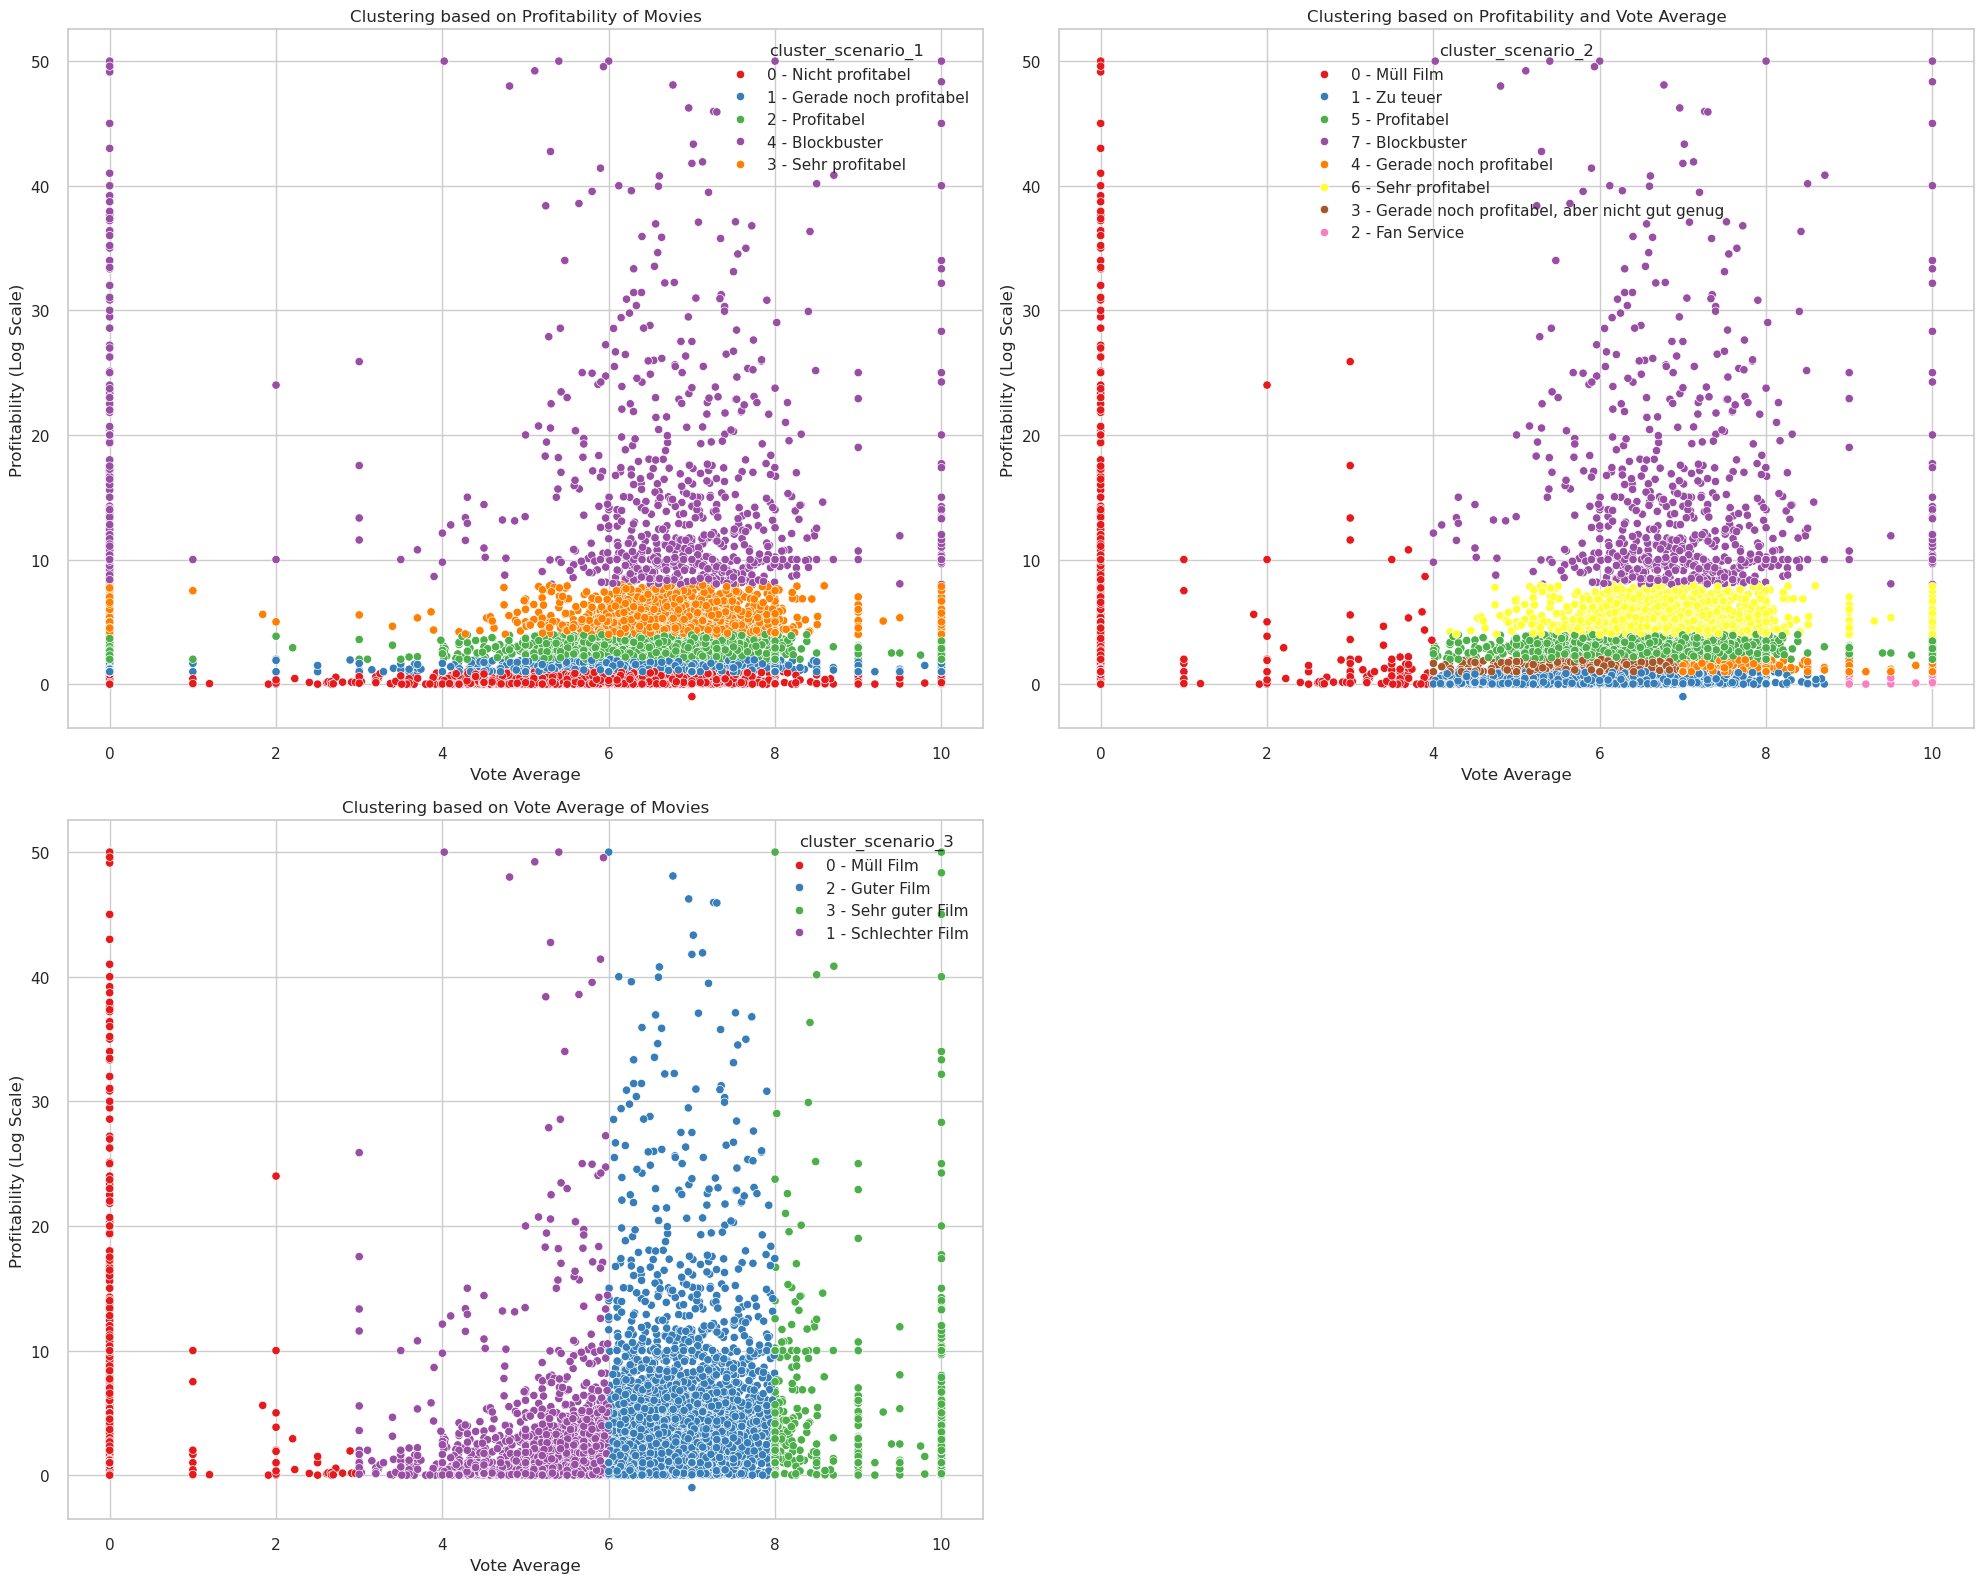

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Scenario 1
sns.scatterplot(
  x='vote_average', y='profitability', hue='cluster_scenario_1',
  data=df_clustered, palette='Set1', ax=axes[0, 0]
)
axes[0, 0].set_title('Clustering based on Profitability of Movies')
axes[0, 0].set_xlabel('Vote Average')
axes[0, 0].set_ylabel('Profitability (Log Scale)')

# Scenario 2
sns.scatterplot(
  x='vote_average', y='profitability', hue='cluster_scenario_2',
  data=df_clustered, palette='Set1', ax=axes[0, 1]
)
axes[0, 1].set_title('Clustering based on Profitability and Vote Average')
axes[0, 1].set_xlabel('Vote Average')
axes[0, 1].set_ylabel('Profitability (Log Scale)')

# Scenario 3
sns.scatterplot(
  x='vote_average', y='profitability', hue='cluster_scenario_3',
  data=df_clustered, palette='Set1', ax=axes[1, 0]
)
axes[1, 0].set_title('Clustering based on Vote Average of Movies')
axes[1, 0].set_xlabel('Vote Average')
axes[1, 0].set_ylabel('Profitability (Log Scale)')

# Hide the unused subplot (bottom right)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## RAM Cleanup

In [15]:
# save the dataframe to a csv file
write_df_to_csv(df_clustered, '30_clustering.csv')

del df_clustered

import gc
gc.collect()

157

## Where to go from here?

![Img](assets/now_what.jpg)

Im Anschluss an das Clustering haben wir damit begonnen, Modelle zu erstellen, um die Profitabilität und Bewertung von Filmen vorherzusagen. Wir haben dafür unter anderem Decision Trees und XGBoost verwendet.
Allerdings hat sich relativ schnell herausgestellt, dass der Datensatz mittlerweile zu klein geworden ist und die Modelle nicht mehr wirklich effektiv sind.

Daher haben wir uns entschieden, in einer weiteren Version des Projekts, den Datensatz zu überdenken, zu erweitern und einen neuen Ansatz zu wählen.